In [ ]:
import pandas as pd
from google.colab import drive
from google.cloud import bigquery

Data Loading (Google Drive Mount)

---

#### **※ Before Data Loading, each member MUST setup:**
1. **Add Shortcut**: Open the shared folder by athallah at WA group "exchangeratedataset", right-click `info_kurs.CSV`, and select **"Organize" > "Add shortcut"**.
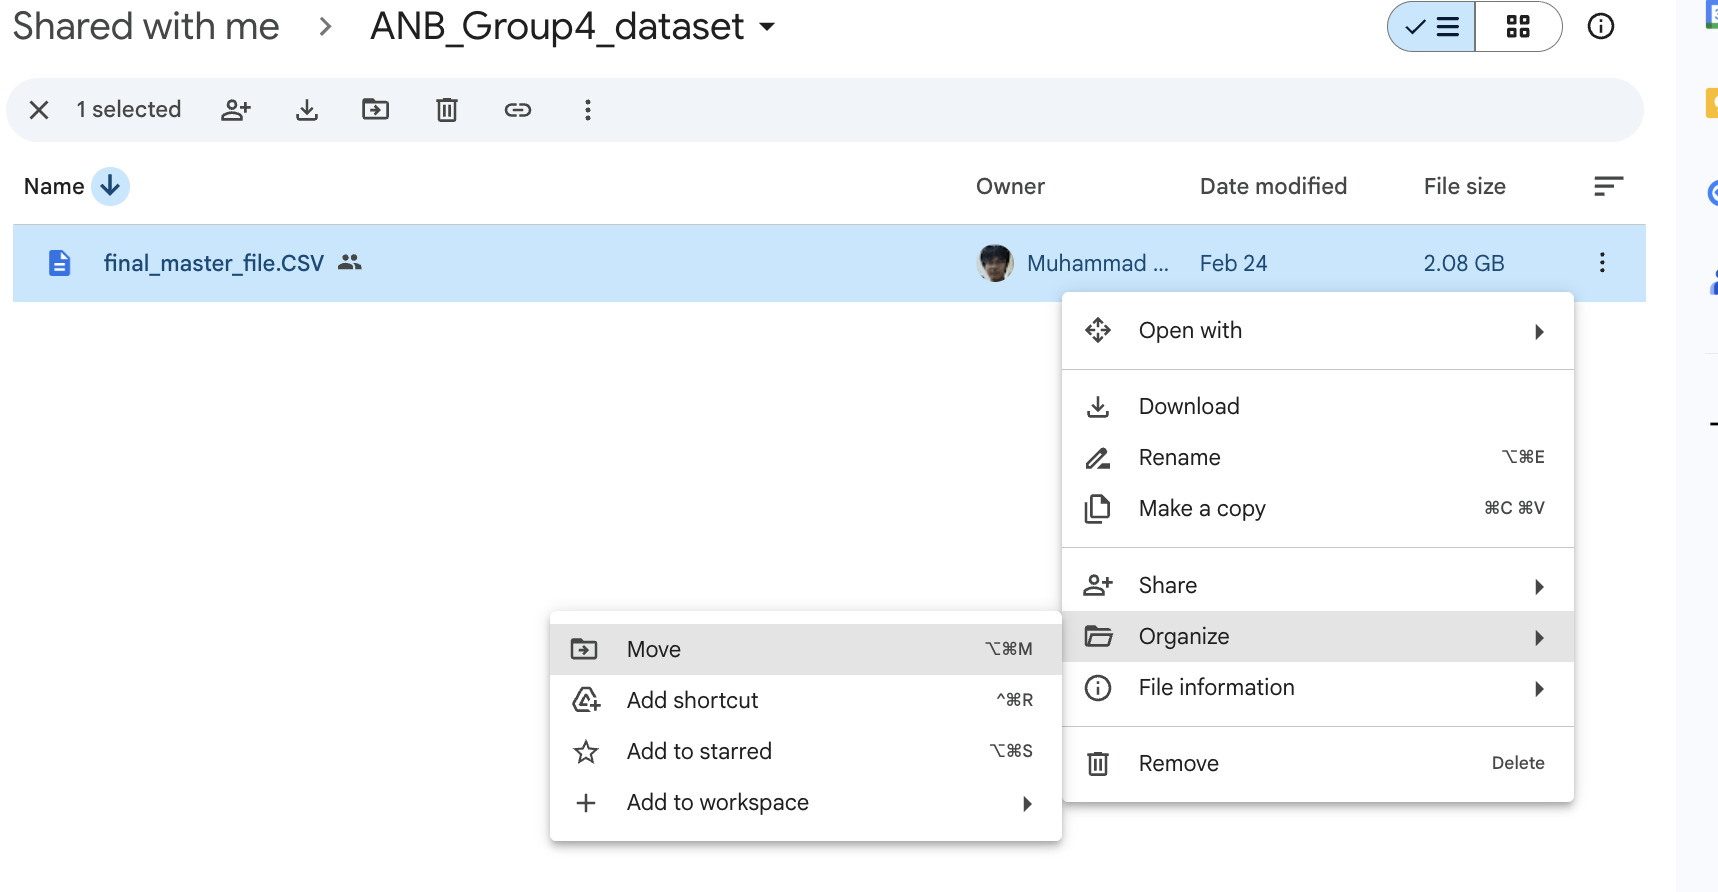

2. **Location**: Save the shortcut directly in your **"My Drive"** (NOT inside any subfolders).
3. **Naming**: Ensure the shortcut name is exactly `info_kurs.CSV`.

This ensures that the `file_path` below works for everyone without any modification.

In [ ]:
# Load CSV, skipping the top 4 metadata/blank rows
drive.mount("/content/drive")
file_path = "/content/drive/MyDrive/exchangeratedataset/info_kurs.csv"
df = pd.read_csv(file_path, skiprows=4)

# Drop unnecessary 'NO' column
if 'NO' in df.columns:
    df = df.drop(columns=['NO'])

# Ensure numeric data type for exchange rate strip ' 12:00:00 AM' substring completely and clean whitespace
df['Kurs'] = pd.to_numeric(df['Kurs'], errors='coerce')
df['Tanggal'] = (
    df['Tanggal']
    .astype(str)
    .str.replace(' 12:00:00 AM', '', regex=False)
    .str.strip()
)

# Parse dates then sort ascending (oldest to newest for ML feature creation)
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%m/%d/%Y')
df = df.sort_values(by='Tanggal').reset_index(drop=True)

# Save clean baseline
df.to_csv("jisdor_cleaned.csv", index=False)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     Tanggal   Kurs
0 2021-09-01  14284
1 2021-09-02  14281
2 2021-09-03  14261
3 2021-09-06  14239
4 2021-09-07  14195
